In [7]:
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import rioxarray as rxr
import rasterio
import easysnowdata
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm, to_rgb
from matplotlib.patches import Patch, Rectangle
from matplotlib_scalebar.scalebar import ScaleBar
from shapely.geometry import box, LineString, Point

In [8]:
classes = {
            1: {"name": "Tundra", "color": "#a100c8"},
            2: {"name": "Boreal Forest", "color": "#00a0fe"},
            3: {"name": "Maritime", "color": "#fe0000"},
            4: {"name": "Ephemeral (includes no snow)", "color": "#e7dc32"},
            5: {"name": "Prairie", "color": "#f08328"},
            6: {"name": "Montane Forest", "color": "#00dc00"},
            7: {"name": "Ice (glaciers and ice sheets)", "color": "#aaaaaa"},
            8: {"name": "Ocean", "color": "#0000ff"},
            9: {"name": "Fill", "color": "#ffffff"},
        }

In [9]:
target_crs = "+proj=stere +lat_0=90 +lat_ts=71 +lon_0=-115 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
NH_box = [-180, 18, 180, 90]
snow_class_map_da = rxr.open_rasterio('data/coarse_snow_class_map/SnowClass_GL_05km_2.50arcmin_2021_v01.0.tif').squeeze().rio.clip_box(*NH_box, crs='EPSG:4326').rio.reproject(target_crs, resolution=5000, resampling=rasterio.enums.Resampling.mode,nodata=9)
snow_class_map_da

<xarray.DataArray (y: 3602, x: 3597)> Size: 13MB
array([[9, 9, 9, ..., 9, 9, 9],
       [9, 9, 9, ..., 9, 9, 9],
       [9, 9, 9, ..., 9, 9, 9],
       ...,
       [9, 9, 9, ..., 9, 9, 9],
       [9, 9, 9, ..., 9, 9, 9],
       [9, 9, 9, ..., 9, 9, 9]], shape=(3602, 3597), dtype=uint8)
Coordinates:
  * y            (y) float64 29kB 9.002e+06 8.997e+06 ... -8.998e+06 -9.003e+06
  * x            (x) float64 29kB -8.975e+06 -8.97e+06 ... 9e+06 9.005e+06
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    Band_1:         Band 1
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      Band 1
    _FillValue:     9

In [10]:
SNOW_CLASS_TIF = 'data/coarse_snow_class_map/SnowClass_GL_05km_2.50arcmin_2021_v01.0.tif'
CHIPS_ZARR = 'data/comparison_datasets/runoff_onset_snow_pillow_station_chips.zarr'
BUFFER_RADIUS_M = 1000  # station-sample footprint: 80 m pixels within 1 km of each station

# short display labels (drop the parentheticals for Ephemeral / Ice)
short_name = lambda i: classes[i]['name'].split(' (')[0]

# Sturm & Liston (2021) Table 1: global class area and % of seasonal-snow area
STURM_LISTON_AREA_MKM2 = {          # 10^6 km^2
    "Tundra": 13.7, "Boreal Forest": 12.2, "Montane Forest": 6.0,
    "Prairie": 10.5, "Maritime": 0.7,
    "Ice": 14.6, "Ephemeral": 89.5,  # excluded from the table's % normalisation
}
STURM_LISTON_PCT = {"Tundra": 31.8, "Boreal Forest": 28.3, "Montane Forest": 13.8,
                    "Prairie": 24.4, "Maritime": 1.7}
SEASONAL_CLASSES = list(STURM_LISTON_PCT)   # the five classes the table normalises over

# categorical colormap keyed to the Sturm & Liston (2021) class colors defined above
CLASS_IDS = list(classes.keys())
class_cmap = ListedColormap([classes[i]["color"] for i in CLASS_IDS])
class_norm = BoundaryNorm([i - 0.5 for i in CLASS_IDS] + [CLASS_IDS[-1] + 0.5], class_cmap.N)

# our snow pillow station locations (the sites used in the comparison)
max_swe_timing_ds = xr.open_zarr('data/comparison_datasets/max_snow_pillow_swe_timing.zarr')
station_gdf = gpd.GeoDataFrame(
    {'station_id': max_swe_timing_ds['station_id'].values},
    geometry=gpd.points_from_xy(max_swe_timing_ds['longitude'].values,
                                max_swe_timing_ds['latitude'].values),
    crs='EPSG:4326',
)
station_proj = station_gdf.to_crs(target_crs)

# number of 80 m pixels sampled in each snow class: every pixel within BUFFER_RADIUS_M of a
# station (the snow_class field is static per chip, so this counts the sampled footprint).
chips_ds = xr.open_zarr(CHIPS_ZARR)
radius = np.sqrt(chips_ds['x_rel'] ** 2 + chips_ds['y_rel'] ** 2)
sampled_snow_class = chips_ds['snow_class'].where(radius <= BUFFER_RADIUS_M).values.ravel()
sampled_snow_class = sampled_snow_class[~np.isnan(sampled_snow_class)].astype(int)

BAR_EXCLUDE = {8, 9}  # Ocean / Fill are not snow classes
snow_class_pixel_counts = pd.Series(sampled_snow_class).value_counts()
snow_class_pixel_counts = snow_class_pixel_counts[
    [i for i in snow_class_pixel_counts.index if i not in BAR_EXCLUDE]
].sort_values(ascending=False)  # descending by pixel count

print(f"{len(station_gdf)} stations, {len(sampled_snow_class):,} sampled 80 m pixels")
snow_class_pixel_counts.rename({i: short_name(i) for i in snow_class_pixel_counts.index})

1210 stations, 591,690 sampled 80 m pixels


Montane Forest    273949
Boreal Forest     100608
Maritime          100517
Prairie            49653
Ephemeral          36967
Tundra             29776
Ice                  118
Name: count, dtype: int64

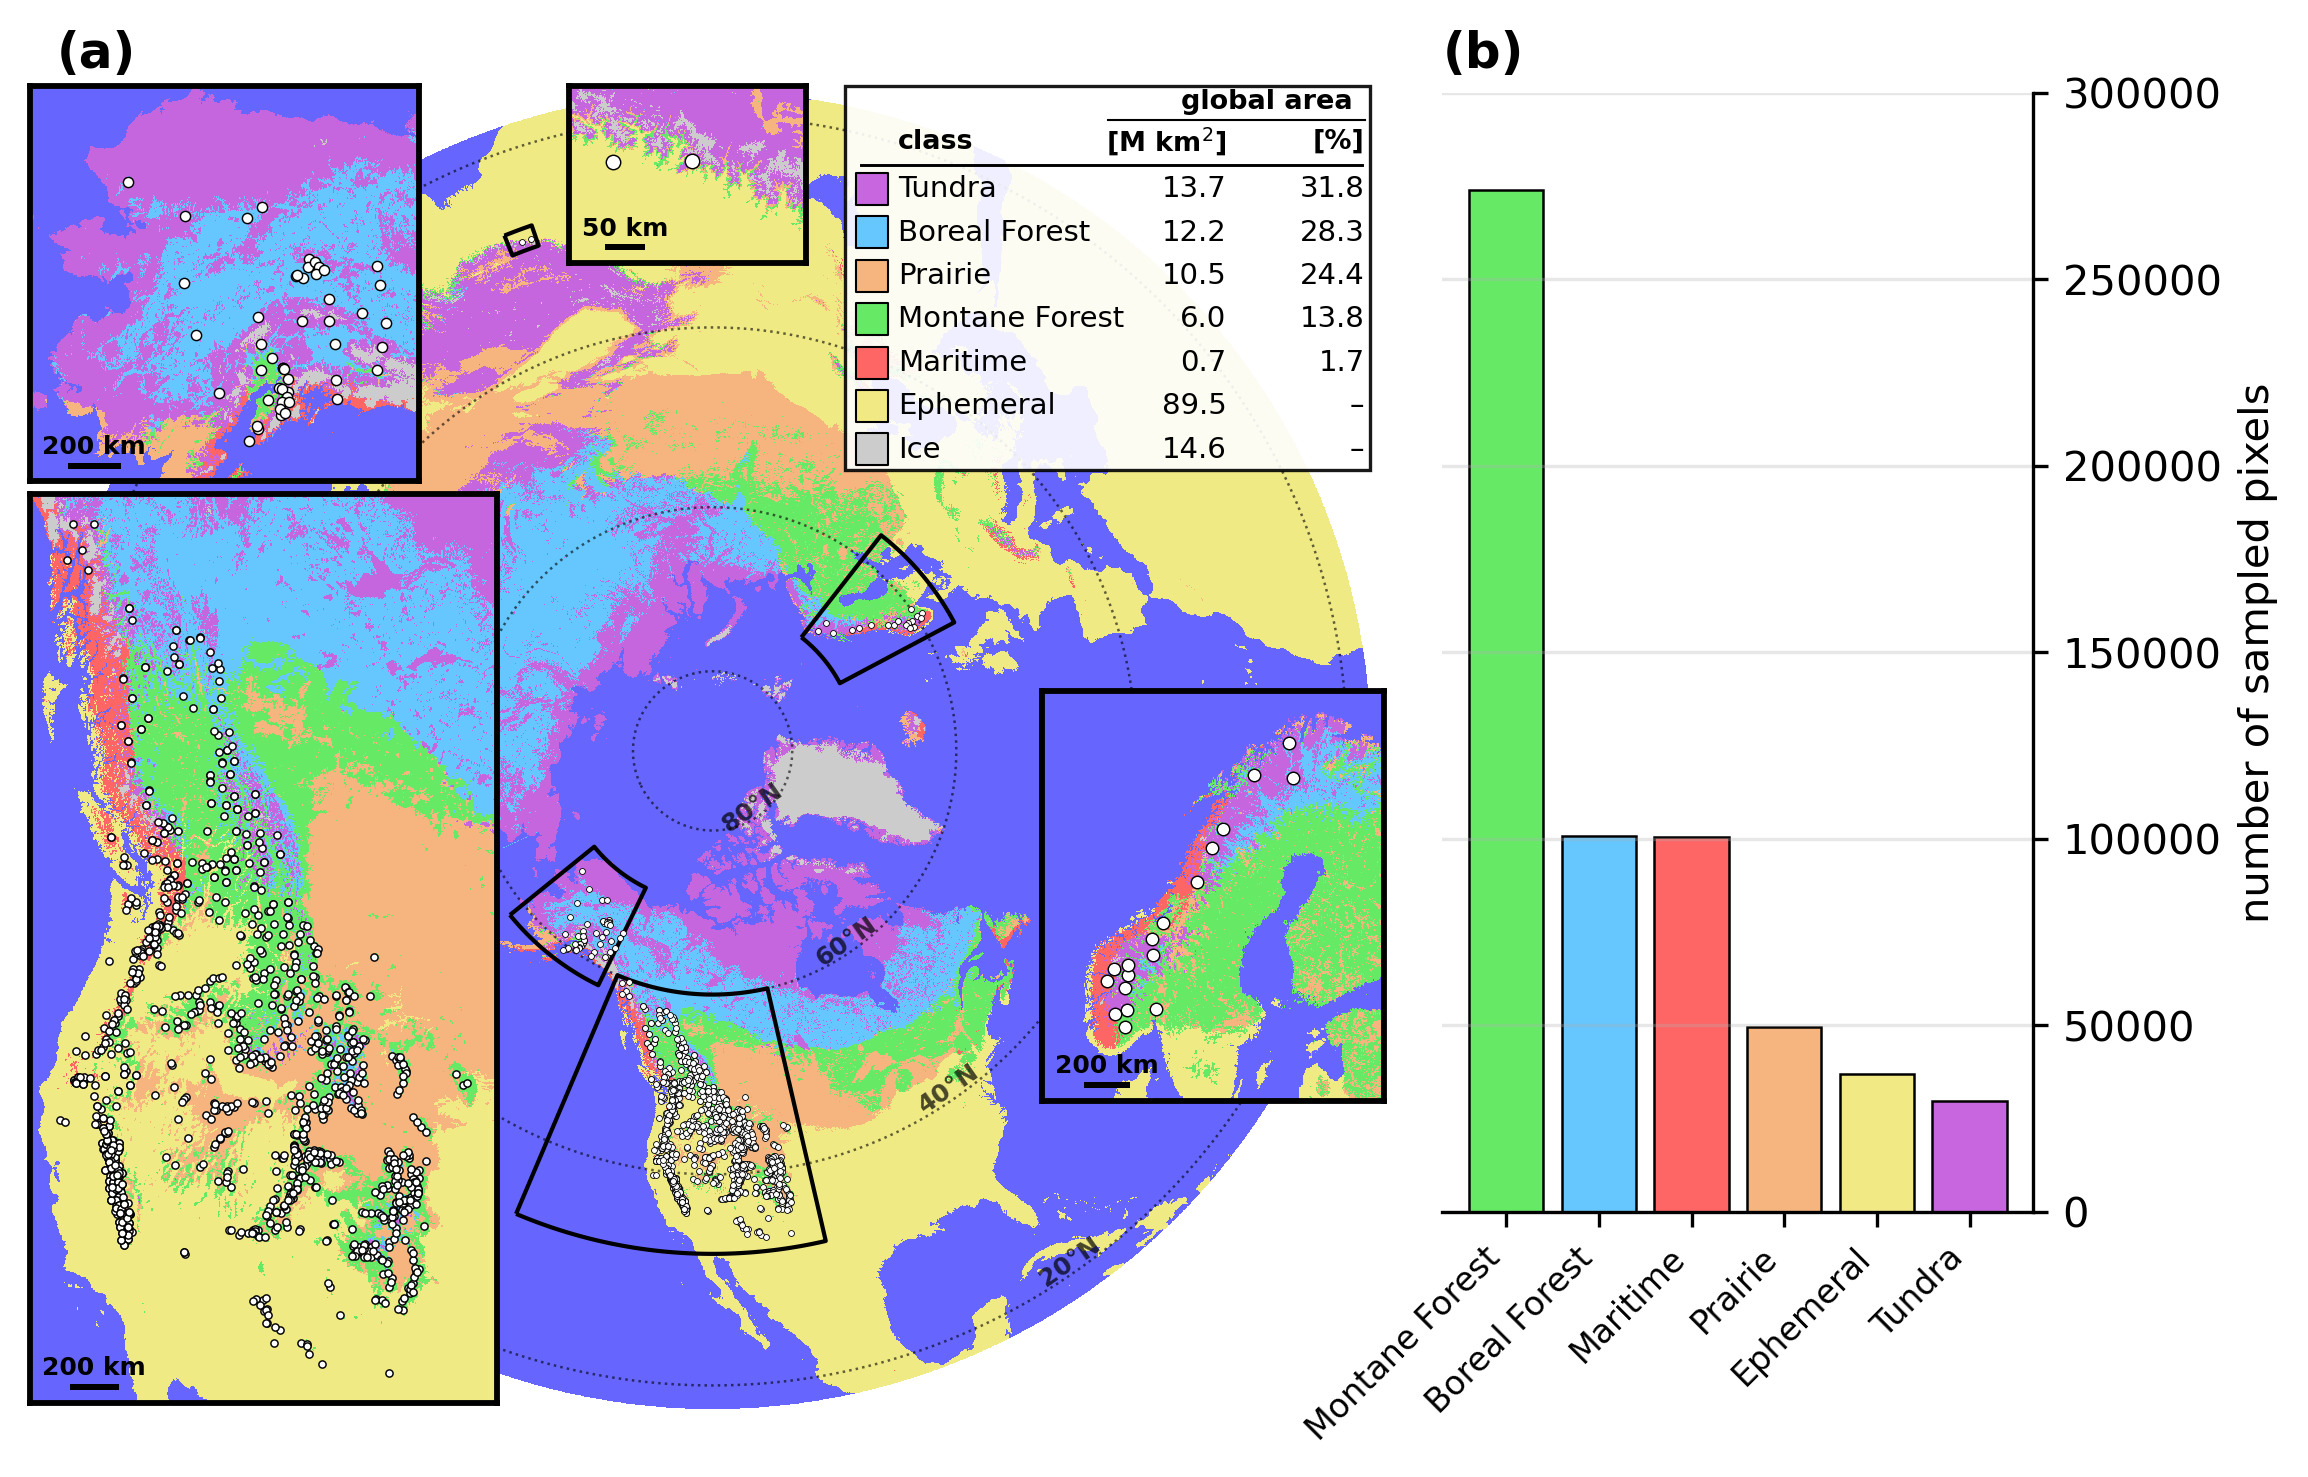

In [14]:
# three-column representativeness figure:
#   (a) Sturm & Liston snow classification map (NH polar stereographic) with our station
#       locations as white/black markers + regional zoom insets & scale bars (layout mirrors the
#       regional-insets cell in 3_evaluate_snow_pillows.ipynb)
#   legend table: each class's global area / % global area (Sturm & Liston 2021, Table 1)
#   (b) number of sampled 80 m pixels (within 1 km of a station) in each snow class, same
#       colors, sorted descending

# --- regional insets over the polar map: equal-area zooms ---
REGIONS = {
    'Western North America': dict(bbox=[-138, 32, -102, 60], s=1, lw=0.4,
                                  inset=[-0.02, 0.005, 0.36, 0.69], anchor='SW',
                                  proj_lon0=-95, extent='stations', margin_km=120),
    'Alaska':                dict(bbox=[-166, 58, -141, 71], s=2, lw=0.5,
                                  inset=[-0.02, 0.705, 0.34, 0.30], anchor='SW',
                                  margin_km=120),
    'Norway':                dict(bbox=[3, 56.5, 27, 72], s=3, lw=0.6,
                                  inset=[0.75, 0.17, 0.26, 0.44], anchor='E'),
    # Nepal uses the higher-resolution (~300 m) easysnowdata product instead of the 5 km tif
    'Nepal':                 dict(bbox=[84, 27, 87, 29], s=4, lw=0.8,
                                  inset=[0.39, 0.855, 0.18, 0.15], anchor='NW',
                                  hires=True, pad_lon=1.5, pad_lat=1.5, hires_res=1000),
}
PAD_LON, PAD_LAT = 12, 6       # extra context so each rectangular inset frame is fully filled
SCALEBAR_THICKNESS_IN = 0.02   # absolute bar thickness on the figure, same for every inset
MAP_ALPHA = 0.6             # background snow-class map faded toward white so the markers pop
MARKER_SCALE = 3             # multiplier applied to the per-inset marker sizes below

# Fade the class colors toward white *in the colors themselves* rather than via an imshow
# alpha. imshow alpha blends each image toward its own axes background (white for the main map,
# ocean-blue for the insets via set_facecolor), so a single alpha faded the two inconsistently.
# Mixing (1 - MAP_ALPHA) of white into each color fades everything identically and lets the
# legend swatches / bar chart reuse the exact displayed colors. (alpha over white == this mix.)
def _fade(color, alpha=MAP_ALPHA):
    r, g, b = to_rgb(color)
    return tuple(c + (1 - c) * (1 - alpha) for c in (r, g, b))

faded_color = {i: _fade(classes[i]["color"]) for i in classes}
faded_cmap = ListedColormap([faded_color[i] for i in CLASS_IDS])

# high-contrast station marker: white fill + black edge so points stand out on the busy map
MARKER_KW = dict(marker="o", facecolor="white", edgecolor="black")


def region_aea_proj(bbox, lon0=None):
    """Albers equal-area projection centered on the region, standard parallels at 1/6 span.

    lon0 east of the region rotates it clockwise (used to stand the NW-SE WNA band up)."""
    lon1, lat1, lon2, lat2 = bbox
    lat_span = lat2 - lat1
    if lon0 is None:
        lon0 = (lon1 + lon2) / 2
    return (f"+proj=aea +lon_0={lon0} +lat_0={(lat1 + lat2) / 2} "
            f"+lat_1={lat1 + lat_span / 6} +lat_2={lat2 - lat_span / 6} "
            f"+datum=WGS84 +units=m +no_defs")


def bbox_ring(bbox, n=100):
    """Densified lon/lat outline of a bbox (curves when projected to a conic/polar CRS)."""
    lon1, lat1, lon2, lat2 = bbox
    lons = np.linspace(lon1, lon2, n)
    lats = np.linspace(lat1, lat2, n)
    return LineString([(x, lat1) for x in lons] + [(lon2, y) for y in lats]
                      + [(x, lat2) for x in lons[::-1]] + [(lon1, y) for y in lats[::-1]])


def reproject_classes(dst_crs, clip_bbox):
    """Clip the native 5 km snow-class raster to a lon/lat bbox and reproject (mode resampling)."""
    lat_range = clip_bbox[1] - clip_bbox[3]
    res = 5000 * (lat_range / 80)  # scale the resolution with latitude span
    return (rxr.open_rasterio(SNOW_CLASS_TIF).squeeze()
            .rio.clip_box(*clip_bbox, crs='EPSG:4326')
            .rio.reproject(dst_crs, resolution=res,
                           resampling=rasterio.enums.Resampling.mode, nodata=9))


def hires_region_classes(dst_crs, clip_bbox, res):
    """Fetch the ~300 m easysnowdata snow classification for a bbox and reproject (mode)."""
    return (easysnowdata.remote_sensing
            .get_seasonal_snow_classification(tuple(clip_bbox), mask_nodata=False)
            .rio.reproject(dst_crs, resolution=res,
                           resampling=rasterio.enums.Resampling.mode))


# --- figure layout: map | class legend table | bar chart ---
fig = plt.figure(figsize=(8.6, 5.7), dpi=300)
gs = fig.add_gridspec(1, 2, width_ratios=[2.3, 1.0], wspace=0.05)

# =========================== (a) snow classification map ===========================
ax_map = fig.add_subplot(gs[0, 0])
snow_class_map_da.plot.imshow(ax=ax_map, cmap=faded_cmap, norm=class_norm,
                              add_colorbar=False, interpolation='nearest', zorder=0)
map_bounds_gdf = gpd.GeoDataFrame(geometry=[box(*snow_class_map_da.rio.bounds())], crs=target_crs)

# our station locations: black dots
ax_map.scatter(station_proj.geometry.x,
               station_proj.geometry.y,
               s=2,
               linewidths=0.2,
               zorder=5,
               **MARKER_KW,
               )

ax_map.set_aspect('equal')
ax_map.set_anchor('N')
ax_map.axis('off')
ax_map.set_title('')
ax_map.set_title('(a)', loc='left', fontsize=12, fontweight='bold', y=1.0)

# latitude circles + labels
target_latitudes = [80, 60, 40, 20]
lons = np.linspace(-180, 180, 361)
lat_lines_gdf = gpd.GeoDataFrame(
    {'latitude': target_latitudes},
    geometry=[LineString([(lon, lat) for lon in lons]) for lat in target_latitudes],
    crs='EPSG:4326').to_crs(target_crs)
lat_lines_gdf = gpd.clip(lat_lines_gdf, map_bounds_gdf)
lat_lines_gdf.plot(ax=ax_map, color='black', linewidth=0.6, linestyle=':', alpha=0.6, zorder=1)

label_angle_deg = -55
theta = np.deg2rad(label_angle_deg)
pole_xy = gpd.GeoSeries([Point(0, 90)], crs='EPSG:4326').to_crs(target_crs).iloc[0]
pole_x, pole_y = pole_xy.x, pole_xy.y
label_offset = -150_000
for _, row in lat_lines_gdf.iterrows():
    coords = np.array(row.geometry.coords)
    angles = np.arctan2(coords[:, 1] - pole_y, coords[:, 0] - pole_x)
    angle_diff = np.angle(np.exp(1j * (angles - theta)))
    idx = np.argmin(np.abs(angle_diff))
    x_lab, y_lab = coords[idx]
    x_lab += label_offset * np.cos(theta)
    y_lab += label_offset * np.sin(theta)
    ax_map.text(x_lab, y_lab, f"{int(row['latitude'])}°N",
                fontsize=6, color='black', alpha=0.7, fontweight='bold', ha='center', va='center',
                rotation=label_angle_deg + 90, rotation_mode='anchor', zorder=1)

# --- regional insets (equal-area) + source boxes on the polar map ---
inset_axes_list = []
for region, cfg in REGIONS.items():
    bbox = cfg['bbox']
    aea = region_aea_proj(bbox, lon0=cfg.get('proj_lon0'))
    ring = bbox_ring(bbox)

    # outline the source region on the polar map
    gpd.GeoSeries([bbox_ring(cfg.get('outline_bbox', bbox))], crs='EPSG:4326').to_crs(target_crs).plot(
        ax=ax_map, color='black', linewidth=1.0, linestyle='-', zorder=3)

    ax_in = ax_map.inset_axes(cfg['inset'], zorder=12)
    inset_axes_list.append(ax_in)
    ax_in.set_facecolor(faded_color[8])  # faded ocean tone for any uncovered corners

    # clip well beyond the bbox so the rectangular display extent is fully covered
    pad_lon = cfg.get('pad_lon', PAD_LON)
    pad_lat = cfg.get('pad_lat', PAD_LAT)
    pad_bbox = [max(bbox[0] - pad_lon, -180), max(bbox[1] - pad_lat, -90),
                min(bbox[2] + pad_lon, 180), min(bbox[3] + pad_lat, 90)]
    if cfg.get('hires'):
        region_classes = hires_region_classes(aea, pad_bbox, cfg.get('hires_res', 400))
    else:
        region_classes = reproject_classes(aea, pad_bbox)
    region_classes.plot.imshow(ax=ax_in, cmap=faded_cmap, norm=class_norm,
                               add_colorbar=False, interpolation='nearest', zorder=0)

    # include stations from the padded area too, so no visible gaps inside the rectangle
    in_box = station_gdf.cx[pad_bbox[0]:pad_bbox[2], pad_bbox[1]:pad_bbox[3]].to_crs(aea)
    ax_in.scatter(in_box.geometry.x,
                  in_box.geometry.y,
                  s=cfg['s'] * MARKER_SCALE,
                  linewidths=0.35,
                  zorder=2,
                  **MARKER_KW,
                  )

    if cfg.get('extent') == 'stations':
        # tight rectangular extent around the region's stations (trims open ocean)
        st = station_gdf.cx[bbox[0]:bbox[2], bbox[1]:bbox[3]].to_crs(aea)
        m = cfg.get('margin_km', 120) * 1000
        xmin, xmax = st.geometry.x.min() - m, st.geometry.x.max() + m
        ymin, ymax = st.geometry.y.min() - m, st.geometry.y.max() + m
    else:
        # rectangular display extent circumscribing the projected bbox (curved edges cropped)
        xmin, ymin, xmax, ymax = gpd.GeoSeries([ring], crs='EPSG:4326').to_crs(aea).total_bounds
    ax_in.set_xlim([xmin, xmax])
    ax_in.set_ylim([ymin, ymax])
    ax_in.set_aspect('equal')
    ax_in.set_anchor(cfg.get('anchor', 'C'))
    ax_in.set_title('')
    ax_in.set_xlabel(''); ax_in.set_ylabel('')
    ax_in.set_xticks([]); ax_in.set_yticks([])
    for spine in ax_in.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.4)

# scale bars: same absolute thickness on the figure for every inset. width_fraction is relative
# to each axes' height and aspect='equal' shrinks each drawn box differently, so lay out the
# figure first and measure the final heights.
fig.canvas.draw()
for ax_in in inset_axes_list:
    ax_height_in = ax_in.get_window_extent().height / fig.dpi
    ax_in.add_artist(ScaleBar(1, units='m', location='lower left', box_alpha=0.0,
                              font_properties={'size': 6, 'weight': 'bold'}, color='black',
                              length_fraction=0.25, frameon=False,
                              width_fraction=SCALEBAR_THICKNESS_IN / ax_height_in,
                              scale_loc='top', sep=1))

# =============== class legend table: global area / % global area (Sturm & Liston 2021) ===============
name_to_id = {short_name(i): i for i in range(1, 8)}
legend_order = sorted(STURM_LISTON_PCT, key=STURM_LISTON_PCT.get, reverse=True) + ['Ephemeral', 'Ice']

# drawn as a translucent overlay on the map's upper-right (over N Africa), not its own panel
tr = ax_map.transAxes
x_sw, x_name, x_area, x_pct = 0.620, 0.640, 0.89, 0.995
y0, dy = 0.927, 0.033
div_y = y0 + 0.018        # main rule (tight above the Tundra row)
sub_y = y0 + 0.036        # sub-header row: class / [M km^2] / [%]
grp_line_y = y0 + 0.052   # thin rule under 'global area'
grp_y = y0 + 0.066        # 'global area' group header
box_left, box_right, box_top = 0.60, 0.999, y0 + 0.078
box_bot = y0 - 6 * dy - 0.016
ax_map.add_patch(Rectangle((box_left, box_bot), box_right - box_left, box_top - box_bot,
                           transform=tr, facecolor='white', alpha=0.9, edgecolor='black',
                           lw=0.8, clip_on=False, zorder=8))
# two-tier header: 'global area' grouped over the [M km^2] and [%] sub-columns
ax_map.text((x_area + x_pct) / 2 - 0.022, grp_y, 'global area', transform=tr, fontsize=6.5,
            fontweight='bold', ha='center', va='center', zorder=10)
ax_map.plot([x_area - 0.09, x_pct], [grp_line_y, grp_line_y], transform=tr, color='black', lw=0.5, zorder=10)
ax_map.text(x_name, sub_y, 'class', transform=tr, fontsize=6.5, fontweight='bold', ha='left', va='center', zorder=10)
ax_map.text(x_area, sub_y, '[M km$^2$]', transform=tr, fontsize=6.5, fontweight='bold', ha='right', va='center', zorder=10)
ax_map.text(x_pct, sub_y, '[%]', transform=tr, fontsize=6.5, fontweight='bold', ha='right', va='center', zorder=10)
ax_map.plot([box_left + 0.012, box_right - 0.006], [div_y, div_y], transform=tr, color='black', lw=0.7, zorder=10)
for k, nm in enumerate(legend_order):
    y = y0 - k * dy
    cid = name_to_id[nm]
    ax_map.scatter(x_sw, y, transform=tr, marker='s', s=60, facecolor=faded_color[cid],
                   edgecolor='black', linewidths=0.5, clip_on=False, zorder=10)
    ax_map.text(x_name, y, nm, transform=tr, fontsize=7, ha='left', va='center', zorder=10)
    ax_map.text(x_area, y, f"{STURM_LISTON_AREA_MKM2[nm]:.1f}", transform=tr, fontsize=7, ha='right', va='center', zorder=10)
    pct = f"{STURM_LISTON_PCT[nm]:.1f}" if nm in STURM_LISTON_PCT else '–'
    ax_map.text(x_pct, y, pct, transform=tr, fontsize=7, ha='right', va='center', zorder=10)

# =========================== (b) pixels sampled per snow class (Ice dropped: negligible) ===========================
bar_counts = snow_class_pixel_counts.drop(7, errors='ignore')  # drop Ice (id 7) from the bar only
bar_names = [short_name(i) for i in bar_counts.index]
bar_colors = [faded_color[i] for i in bar_counts.index]
# shrink the bar vertically (top of its cell) so the rotated labels fit inside the cell,
# keeping the map free of whitespace below it
gs_bar = gs[0, 1].subgridspec(2, 1, height_ratios=[0.85, 0.15], hspace=0.0)
ax_bar = fig.add_subplot(gs_bar[0, 0])
ax_bar.bar(range(len(bar_counts)), bar_counts.values,
           color=bar_colors, edgecolor='black', linewidth=0.6)
ax_bar.set_xticks(range(len(bar_counts)))
ax_bar.set_xticklabels(bar_names, rotation=45, ha='right', fontsize=8)
ax_bar.set_ylabel('number of sampled pixels')
ax_bar.set_title('(b)', loc='left', fontsize=12, fontweight='bold')
ax_bar.yaxis.set_label_position('right')
ax_bar.yaxis.tick_right()
ax_bar.spines['top'].set_visible(False)
ax_bar.spines['left'].set_visible(False)
ax_bar.grid(axis='y', alpha=0.3)

ax_bar.set_ylim(0,300000)


fig.savefig('figures/snow_pillow_representativeness_snow_class_map_and_pixel_counts.png',
            bbox_inches='tight', dpi=300)